In [27]:
from langchain_community.tools import DuckDuckGoSearchRun
search_tool=DuckDuckGoSearchRun(description="tool to search")
search_tool.invoke("Whhat is the capital of India")

'13 Feb 2026·On 10 February 1931, Delhi officially became the capital of India during British rule, replacing Calcutta. This decision was taken to establish a centrally ... 1 Feb 2026·Why Did Delhi Become the Capital of India? | History Explained in 60 Seconds Why was Delhi chosen as the capital of India instead of Kolkata or Mumbai? 18 Dec 2025·In 1911, the British shifted the capital from Kolkata to Delhi, and after independence, New Delhi officially became the capital of modern India. This short ... 3 Dec 2025·New Delhi is the capital city of India and serves as the seat of the Government of India. Located in the northern part of the country, New Delhi is part of the ... 13 Feb 2026·#DidYouKnow how did Delhi become the capital of India? The...'

In [28]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(),description="wikipedia search")
wikipedia_tool.invoke("who is donald trump ?")

'Page: List of Republicans who opposed the Donald Trump 2016 presidential campaign\nSummary: This is a list of  Republicans and conservatives who announced their opposition to the election of Donald Trump, the 2016 Republican Party nominee and eventual winner of the election, as the president of the United States. It also includes former Republicans who left the party due to their opposition to Trump and as well as Republicans who endorsed a different candidate. It includes Republican presidential primary election candidates that announced opposition to Trump as the nominee. Some of the Republicans on this list threw their support to Trump after he won the presidential election, while many of them continue to oppose Trump. Offices listed are those held at the time of the 2016 election.\n\nPage: Trump family\nSummary: The Trump family is a prominent wealthy American family. The most well-known member is Donald Trump, the 45th and current 47th president of the United States (2017–2021, 2

In [29]:
from langchain.tools import tool

@tool
def buiseness_enterprise_tool(query: str) -> str:
    """Answer business enterprise queries."""
    return "Work From Home"


In [30]:
ToolKit = [search_tool,wikipedia_tool,buiseness_enterprise_tool]

In [31]:
ToolKit

[DuckDuckGoSearchRun(description='tool to search', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(description='wikipedia search', api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\arunm\\OneDrive\\Desktop\\LangChain_Tutorial\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000)),
 StructuredTool(name='buiseness_enterprise_tool', description='Answer business enterprise queries.', args_schema=<class 'langchain_core.utils.pydantic.buiseness_enterprise_tool'>, func=<function buiseness_enterprise_tool at 0x00000226C33380F0>)]

In [32]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
model=ChatOpenAI(
  model="gpt-4o-mini",
  temperature=0.9,
  max_completion_tokens=1000,
  verbose=True,
  timeout=30
)


In [33]:
agent = create_agent(model=model,tools=ToolKit)

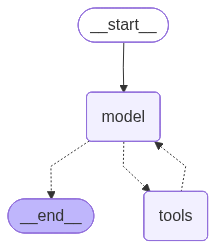

In [34]:
agent

In [35]:
example = "what are the top 5 highest grossing movies in india"
events = agent.stream(
  {"messages":[("user",example)]},
  stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()


================================ Human Message =================================

what are the top 5 highest grossing movies in india
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (call_SDMwz7dkJg6jNp6yvzDM8PmH)
 Call ID: call_SDMwz7dkJg6jNp6yvzDM8PmH
  Args:
    query: highest grossing movies in India 2023
================================= Tool Message =================================
Name: duckduckgo_search

28 Feb 2026·This ranking lists the highest-grossing films in India, based on domestic box office estimates as reported by organizations classified as green by Wikipedia. 17 Jun 2025·The highest grossing Indian films of 2023 are listed here Note : The Indian ... movies by genreTop box officeShowtimes & ticketsMovie newsIndia movie spotlight. 19 Jun 2025·Bollywood's ComeBack Year - 2023 Top 10 Movies Cumulative Gross - 5860 CR ... Bollywood Superstars' Highest-Grossing Blockbusters in India. Mohin ... 26 Dec 2025·H

In [38]:
llm_openai = ChatOpenAI(model="gpt-4o-mini",temperature=0.4)
llm_without_binded = llm_openai.invoke("what is the latest news about stock market ?")
llm_without_binded

AIMessage(content="I don't have access to real-time data or news updates. For the latest news on the stock market, I recommend checking reputable financial news websites, stock market apps, or financial television networks. They provide up-to-date information on market trends, stock performance, and economic indicators.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 16, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_eb37e061ec', 'id': 'chatcmpl-DIIio5iRrh7ru2P03ZU2uePG5DEzt', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cde30-6b7f-7302-b036-a6bdb2980161-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 

In [39]:
llm_with_binded = llm_openai.bind_tools(tools=ToolKit)
llm_with_binded.invoke("what is the latest news about stock market ?")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 106, 'total_tokens': 127, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f97eff32c5', 'id': 'chatcmpl-DIIk9nXehdK5ftpaqLDtXFkADpIR7', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cde31-ac8a-7212-8dd8-4f9ae1aa6dc5-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'latest news stock market'}, 'id': 'call_WqNQhUtMVRoWxdKj3snliXeO', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 106, 'output_tokens': 21, 'total_tokens': 127, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})